In [16]:
# Imports
from pathlib import Path
import pandas as pd
from IPython.display import display_html
import matplotlib.pyplot as plt
import seaborn as sns

# Defining Paths
TRAIN_DIR = Path("../dataset/train")
TEST_DIR = Path("../dataset/test")

In [17]:
# --- 1. Class Distribution ---
def analyze_dataset(dataset_path):
    rows = []

    for class_dir in dataset_path.iterdir():

        if not class_dir.is_dir():
            continue

        images = list(class_dir.glob("*.jpg"))

        rows.append({
            "class": class_dir.name,
            "image_count": len(images)
        })

    return pd.DataFrame(rows)


train_df = analyze_dataset(TRAIN_DIR)
test_df = analyze_dataset(TEST_DIR)

In [18]:
# --- 2. Side by Side Display ---
def display_side_by_side(*dfs, titles=()):
    html_str = '<div style="display: flex; gap: 20px; align-items: flex-start;">'
    for title, df in zip(titles, dfs):
        html_str += f'<div><h3 style="text-align: center;">{title}</h3>' + df.to_html(index=True) + '</div>'
    html_str += '</div>'
    display_html(html_str, raw=True)

display_side_by_side(train_df, test_df, titles=('TRAIN', 'TEST'))

,class,image_count
0,I,4800
1,B,4800
2,J,4800
3,A,4800
4,E,4800
5,nothing,3000
6,M,4800
7,Y,4800
8,P,4800
9,C,4800


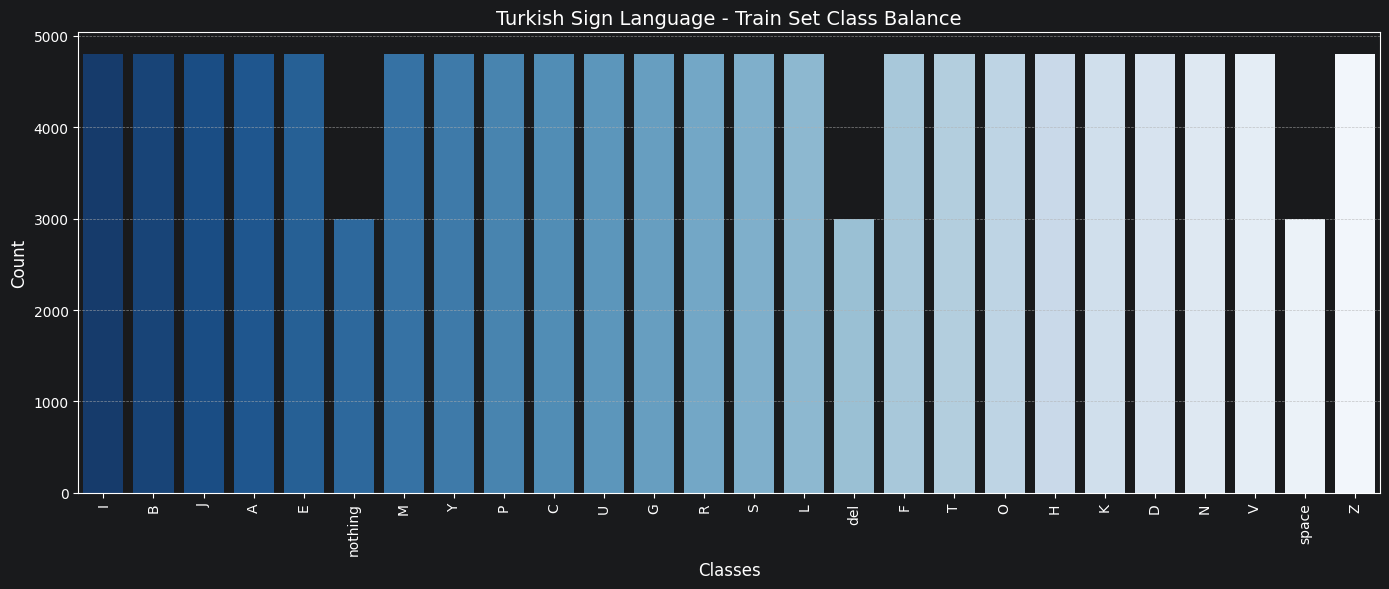

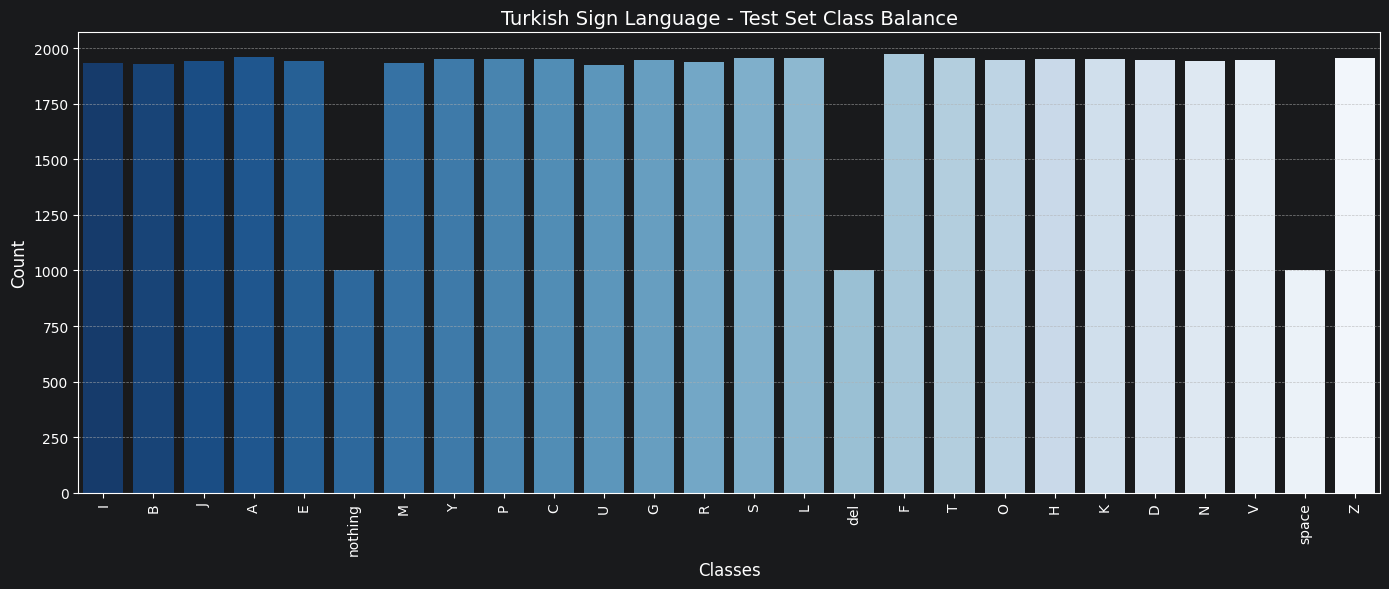

In [20]:
# --- 3. Visualization (Bar Plot) ---
def class_visualization(df, dataset_type="Train"):
    plt.figure(figsize=[14, 6])
    sns.barplot(
        data=df,
        x="class",
        y="image_count",
        hue="class",
        palette="Blues_r",
        legend=False,
    )
    plt.xticks(rotation=90)
    plt.title(f"Turkish Sign Language - {dataset_type} Set Class Balance", fontsize=14)
    plt.xlabel("Classes", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

class_visualization(train_df, dataset_type="Train")
class_visualization(test_df, dataset_type="Test")